In [100]:
# ==========================================================
# Global Random Forest using MLForecast (Nixtla)
# ==========================================================

import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# Nixtla
# ==========================================================

from statsforecast import StatsForecast
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean
from mlforecast.target_transforms import Differences, LocalBoxCox

# ==========================================================
# Machine Learning
# ==========================================================

from sklearn.ensemble import RandomForestRegressor

# ==========================================================
# Metrics
# ==========================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# ==========================================================
# Paths
# ==========================================================

processed_dir = Path("data/processed")
raw_dir = Path("data/raw")

# ==========================================================
# Load Historical Sales Data
# ==========================================================

sales = pd.read_csv(

    processed_dir / "sales_clean.csv",

    parse_dates=["date"],

    low_memory=False

)

# ==========================================================
# Load Future Data
# ==========================================================

future = pd.read_csv(

    processed_dir / "future_clean.csv",

    parse_dates=["date"],

    low_memory=False

)

# ==========================================================
# Load Customer Forecast
# ==========================================================

customer_forecast = pd.read_csv(

    processed_dir / "future_customer_prediction_rf.csv",

    parse_dates=["ds"],

    low_memory=False

)
metadata = pd.read_csv(
    raw_dir / "metadata.csv"
)

print("=" * 60)
print("Historical Sales")
print("=" * 60)
print(sales.head())

print()

print("=" * 60)
print("Future Data")
print("=" * 60)
print(future.head())

print()

print("=" * 60)
print("Future Customer Forecast")
print("=" * 60)
print(customer_forecast.head())

Historical Sales
  store_id       date  sales  customers  open  promo state_holiday  \
0  store_1 2015-07-19      0          0     0      0             0   
1  store_2 2015-07-19      0          0     0      0             0   
2  store_3 2015-07-19      0          0     0      0             0   
3  store_4 2015-07-19      0          0     0      0             0   
4  store_5 2015-07-19      0          0     0      0             0   

   school_holiday store_type assortment  competition_distance  
0               0          c          a                1270.0  
1               0          a          a               14130.0  
2               0          a          c               24000.0  
3               0          a          a                7520.0  
4               0          a          c                2030.0  

Future Data
  store_id       date  open  promo  state_holiday  school_holiday  customers  \
0  store_1 2015-09-17   1.0      1              0               0        NaN   
1  st

In [101]:
# ==========================================================
# Global Random Forest using MLForecast (Nixtla)
# ==========================================================

import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# Nixtla
# ==========================================================

from statsforecast import StatsForecast
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean
from mlforecast.target_transforms import Differences, LocalBoxCox

# ==========================================================
# Machine Learning
# ==========================================================

from sklearn.ensemble import RandomForestRegressor

# ==========================================================
# Metrics
# ==========================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# ==========================================================
# Paths
# ==========================================================

processed_dir = Path("data/processed")
raw_dir = Path("data/raw")

# ==========================================================
# Load Historical Sales Data
# ==========================================================

sales = pd.read_csv(
    processed_dir / "sales_clean.csv",
    parse_dates=["date"],
    low_memory=False
)

# ==========================================================
# Load Future Data
# ==========================================================

future = pd.read_csv(
    processed_dir / "future_clean.csv",
    parse_dates=["date"],
    low_memory=False
)

# ==========================================================
# Load Customer Forecast
# ==========================================================

customer_forecast = pd.read_csv(
    processed_dir / "future_customer_prediction_rf.csv",
    parse_dates=["ds"],
    low_memory=False
)

# ==========================================================
# Remove Empty Customer Column
# ==========================================================

future = future.drop(columns=["customers"])

# ==========================================================
# Sort Data
# ==========================================================

sales = sales.sort_values(
    ["store_id", "date"]
).reset_index(drop=True)

future = future.sort_values(
    ["store_id", "date"]
).reset_index(drop=True)

customer_forecast = customer_forecast.sort_values(
    ["unique_id", "ds"]
).reset_index(drop=True)

# ==========================================================
# Check Data
# ==========================================================

print("=" * 60)
print("Sales")
print("=" * 60)
print(sales.head())

print()

print("=" * 60)
print("Future")
print("=" * 60)
print(future.head())

print()

print("=" * 60)
print("Customer Forecast")
print("=" * 60)
print(customer_forecast.head())

Sales
  store_id       date  sales  customers  open  promo state_holiday  \
0  store_1 2013-01-07   7176        785     1      1             0   
1  store_1 2013-01-08   5580        654     1      1             0   
2  store_1 2013-01-09   5471        626     1      1             0   
3  store_1 2013-01-10   4892        615     1      1             0   
4  store_1 2013-01-11   4881        592     1      1             0   

   school_holiday store_type assortment  competition_distance  
0               1          c          a                1270.0  
1               1          c          a                1270.0  
2               1          c          a                1270.0  
3               1          c          a                1270.0  
4               1          c          a                1270.0  

Future
  store_id       date  open  promo  state_holiday  school_holiday store_type  \
0  store_1 2015-07-20   1.0      0              0               0          c   
1  store_1 2015-07-21

In [102]:
# ==========================================================
# Rename Columns for MLForecast
# ==========================================================

sales = sales.rename(
    columns={
        "store_id": "unique_id",
        "date": "ds",
        "sales": "y",
        "customers": "customer_prediction"
    }
)

future = future.rename(
    columns={
        "store_id": "unique_id",
        "date": "ds"
    }
)

# ==========================================================
# Merge Future Customer Forecast
# ==========================================================

future = future.merge(

    customer_forecast,

    on=[
        "unique_id",
        "ds"
    ],

    how="left"

)

# ==========================================================
# Check Customer Prediction
# ==========================================================

print("=" * 60)
print("Customer Prediction")
print("=" * 60)

print(
    future[
        [
            "unique_id",
            "ds",
            "customer_prediction"
        ]
    ].head()
)

print()

print("Missing customer predictions:")

print(
    future["customer_prediction"]
    .isna()
    .sum()
)

# ==========================================================
# Encode Categorical Features
# ==========================================================

state_holiday_map = {
    "0": 0,
    "a": 1,
    "b": 2,
    "c": 3,
    0: 0,
    0.0: 0
}

store_type_map = {
    "a": 0,
    "b": 1,
    "c": 2,
    "d": 3
}

assortment_map = {
    "a": 0,
    "b": 1,
    "c": 2
}

for df in [sales, future]:
    df["state_holiday"] = (
        df["state_holiday"]
        .replace(state_holiday_map)
        .fillna(0)
        .astype(int)
    )

    df["store_type"] = (
        df["store_type"]
        .map(store_type_map)
        .fillna(df["store_type"])
        .astype(int)
    )

    df["assortment"] = (
        df["assortment"]
        .map(assortment_map)
        .fillna(df["assortment"])
        .astype(int)
    )

# ==========================================================
# Create Additional Dynamic Features
# ==========================================================

# Weekend indicator
sales["is_weekend"] = (
        sales["ds"].dt.dayofweek >= 5
).astype(int)

future["is_weekend"] = (
        future["ds"].dt.dayofweek >= 5
).astype(int)

# Quarter
sales["quarter"] = sales["ds"].dt.quarter
future["quarter"] = future["ds"].dt.quarter

# ISO week number
sales["week_of_year"] = (
    sales["ds"]
    .dt.isocalendar()
    .week
    .astype(int)
)

future["week_of_year"] = (
    future["ds"]
    .dt.isocalendar()
    .week
    .astype(int)
)

# Promotion during weekends
sales["promo_weekend"] = (
        sales["promo"] *
        sales["is_weekend"]
)

future["promo_weekend"] = (
        future["promo"] *
        future["is_weekend"]
)


# Customer × Promotion
sales["customer_promo"] = (
        sales["customer_prediction"] *
        sales["promo"]
)

future["customer_promo"] = (
        future["customer_prediction"] *
        future["promo"]
)

# Customer × Weekend
sales["customer_weekend"] = (
        sales["customer_prediction"] *
        sales["is_weekend"]
)

future["customer_weekend"] = (
        future["customer_prediction"] *
        future["is_weekend"]
)

customer_mean = (
    sales
    .groupby("unique_id")["customer_prediction"]
    .mean()
)
sales["customer_ratio"] = (
    sales["customer_prediction"] /
    sales["unique_id"].map(customer_mean)
)

future["customer_ratio"] = (
    future["customer_prediction"] /
    future["unique_id"].map(customer_mean)
)

# ==========================================================
# Validate Features
# ==========================================================

print("=" * 60)
print("Additional Features")
print("=" * 60)

print(
    sales[
        [
            "unique_id",
            "ds",
            "customer_prediction",
            "promo",
            "customer_promo",
            "customer_weekend",
            "is_weekend",
            "quarter",
            "week_of_year",
            "promo_weekend"
        ]
    ].head()
)

print()

print(
    future[
        [
            "unique_id",
            "ds",
            "customer_prediction",
            "promo",
            "customer_promo",
            "customer_weekend",
            "is_weekend",
            "quarter",
            "week_of_year",
            "promo_weekend"
        ]
    ].head()
)

print()

print("=" * 60)
print("Missing Values")
print("=" * 60)

print(sales.isna().sum())

print()

print(future.isna().sum())

Customer Prediction
  unique_id         ds  customer_prediction
0   store_1 2015-07-20              486.060
1   store_1 2015-07-21              446.065
2   store_1 2015-07-22              461.360
3   store_1 2015-07-23              470.705
4   store_1 2015-07-24              462.035

Missing customer predictions:
12168
Additional Features
  unique_id         ds  customer_prediction  promo  customer_promo  \
0   store_1 2013-01-07                  785      1             785   
1   store_1 2013-01-08                  654      1             654   
2   store_1 2013-01-09                  626      1             626   
3   store_1 2013-01-10                  615      1             615   
4   store_1 2013-01-11                  592      1             592   

   customer_weekend  is_weekend  quarter  week_of_year  promo_weekend  
0                 0           0        1             2              0  
1                 0           0        1             2              0  
2                 0   

In [103]:
print(future.columns.tolist())
print(customer_forecast.head())
future2 = future.merge(
    customer_forecast,
    on=["unique_id", "ds"],
    how="left",
    indicator=True
)

print(future2["_merge"].value_counts())

['unique_id', 'ds', 'open', 'promo', 'state_holiday', 'school_holiday', 'store_type', 'assortment', 'competition_distance', 'customer_prediction', 'is_weekend', 'quarter', 'week_of_year', 'promo_weekend', 'customer_promo', 'customer_weekend', 'customer_ratio']
  unique_id         ds  customer_prediction
0   store_1 2015-07-20              486.060
1   store_1 2015-07-21              446.065
2   store_1 2015-07-22              461.360
3   store_1 2015-07-23              470.705
4   store_1 2015-07-24              462.035
_merge
both          28392
left_only     12168
right_only        0
Name: count, dtype: int64


In [104]:
print("=" * 60)
print("Features Used for Training")
print("=" * 60)
print(sales.columns.tolist())

Features Used for Training
['unique_id', 'ds', 'y', 'customer_prediction', 'open', 'promo', 'state_holiday', 'school_holiday', 'store_type', 'assortment', 'competition_distance', 'is_weekend', 'quarter', 'week_of_year', 'promo_weekend', 'customer_promo', 'customer_weekend', 'customer_ratio']


In [105]:
# ==========================================================
# Hyperparameter Grid
# ==========================================================

parameter_grid = [

    {
        "name": "RF200_SQRT",
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },

    {
        "name": "RF300_SQRT_Leaf5",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 5,
        "max_features": "sqrt"
    }

]

# ==========================================================
# Hyperparameter Tuning using Rolling Forecast Origin CV
# ==========================================================

results = []

for params in parameter_grid:
    print("=" * 60)
    print(params["name"])
    print("=" * 60)

    # ------------------------------------------------------
    # Random Forest
    # ------------------------------------------------------

    model = RandomForestRegressor(

        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        random_state=42,
        n_jobs=-1

    )

    # ------------------------------------------------------
    # MLForecast
    # ------------------------------------------------------

    fcst = MLForecast(

        models=[model],

        freq="D",

        lags=[
            1,
            7,
            14,
            21,
            28
        ],

        lag_transforms={

            7: [
                RollingMean(window_size=4)
            ],

            28: [
                RollingMean(window_size=2)
            ]

        },

        date_features=[
            "dayofweek",
            "month"
        ]

    )

    # ------------------------------------------------------
    # Rolling Forecast Origin Cross Validation
    # ------------------------------------------------------

    cv = fcst.cross_validation(

        df=sales,

        h=42,

        n_windows=3,

        refit=False,

        static_features=[]

    )

    cv.to_csv(

             processed_dir / f"{params['name']}_cv_predictions.csv",
             index=False
     )
    print("CV predictions saved.")

    prediction_col = cv.columns[-1]

    valid = cv["y"] > 0

    mae = mean_absolute_error(
        cv.loc[valid, "y"],
        cv.loc[valid, prediction_col]
    )

    rmse = np.sqrt(
        mean_squared_error(
            cv.loc[valid, "y"],
            cv.loc[valid, prediction_col]
        )
    )

    mape = (
               np.abs(
                   (
                           cv.loc[valid, "y"]
                           - cv.loc[valid, prediction_col]
                   )
                   / cv.loc[valid, "y"]
               )
           ).mean() * 100

    results.append({

        "Model": params["name"],
        "Trees": params["n_estimators"],
        "Leaf": params["min_samples_leaf"],
        "Max Features": params["max_features"],
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape

    })

    print(f"MAE :  {mae:.2f}")
    print(f"RMSE:  {rmse:.2f}")
    print(f"MAPE:  {mape:.2f}%")

# ==========================================================
# Hyperparameter Tuning Results
# ==========================================================

results = pd.DataFrame(results)

results = results.sort_values(
    by="MAPE",
    ascending=True
)

print(results)

results.to_csv(
    processed_dir / "rf_cv_results.csv",
    index=False
)

# ==========================================================
# Select Best Hyperparameters
# ==========================================================

best_result = results.iloc[0]
best_cv = pd.read_csv(

    processed_dir /
    f"{best_result['Model']}_cv_predictions.csv"

)

best_cv.to_csv(

    processed_dir / "rf_best_cv_predictions.csv",

    index=False

)

print("Best CV predictions saved.")

best_model = RandomForestRegressor(

    n_estimators=int(best_result["Trees"]),

    min_samples_leaf=int(best_result["Leaf"]),

    max_features=best_result["Max Features"],

    random_state=42,

    n_jobs=-1

)

# ==========================================================
# Train Final Model
# ==========================================================

final_fcst = MLForecast(

    models=[best_model],

    freq="D",

    lags=[
        1,
        7,
        14,
        21,
        28
    ],

    lag_transforms={

        7: [
            RollingMean(window_size=4)
        ],

        28: [
            RollingMean(window_size=2)
        ]

    },

    date_features=[
        "dayofweek",
        "month"
    ]

)

final_fcst.fit(

    sales,

    static_features=[]

)

print("=" * 60)
print("Best Model")
print("=" * 60)
print(best_result)
print()
print("Final model trained successfully.")
# ==========================================================
# Generate Features for the Final Model
# ==========================================================

features = final_fcst.preprocess(

    sales,

    static_features=[]

)

print("=" * 60)
print("Generated Features")
print("=" * 60)

print(features.head())

print(features.shape)

# ==========================================================
# Create Evaluation Dataset
# ==========================================================

eval_size = 42 * sales["unique_id"].nunique()

train_features = features.iloc[:-eval_size].copy()

test_features = features.iloc[-eval_size:].copy()

# Randomly sample observations to speed up permutation importance
test_features = test_features.sample(

    n=min(5000, len(test_features)),

    random_state=42

)

print("=" * 60)
print("Train Features:", train_features.shape)
print("Test Features :", test_features.shape)

RF200_SQRT
CV predictions saved.
MAE :  567.37
RMSE:  808.99
MAPE:  7.82%
RF300_SQRT_Leaf5
CV predictions saved.
MAE :  584.17
RMSE:  838.13
MAPE:  8.04%
              Model  Trees  Leaf Max Features         MAE        RMSE  \
0        RF200_SQRT    200     1         sqrt  567.371341  808.993246   
1  RF300_SQRT_Leaf5    300     5         sqrt  584.169702  838.131927   

       MAPE  
0  7.822213  
1  8.036313  
Best CV predictions saved.
Best Model
Model           RF200_SQRT
Trees                  200
Leaf                     1
Max Features          sqrt
MAE             567.371341
RMSE            808.993246
MAPE              7.822213
Name: 0, dtype: object

Final model trained successfully.
Generated Features
   unique_id         ds       y  customer_prediction  open  promo  \
29   store_1 2013-02-05  6049.0                  678     1      1   
30   store_1 2013-02-06  6140.0                  693     1      1   
31   store_1 2013-02-07  5499.0                  675     1      1   
32  

Generated Features
   unique_id         ds       y  customer_prediction  open  promo  \
29   store_1 2013-02-05  6049.0                  678     1      1   
30   store_1 2013-02-06  6140.0                  693     1      1   
31   store_1 2013-02-07  5499.0                  675     1      1   
32   store_1 2013-02-08  5681.0                  630     1      1   
33   store_1 2013-02-09  5370.0                  656     1      0   

    state_holiday  school_holiday  store_type  assortment  ...  \
29              0               0           2           0  ...   
30              0               0           2           0  ...   
31              0               0           2           0  ...   
32              0               0           2           0  ...   
33              0               0           2           0  ...   

    customer_ratio    lag1    lag7   lag14   lag21   lag28  \
29        1.449137  7032.0  3725.0  5720.0  3900.0  5580.0   
30        1.481197  6049.0  4601.0  5578.0  4

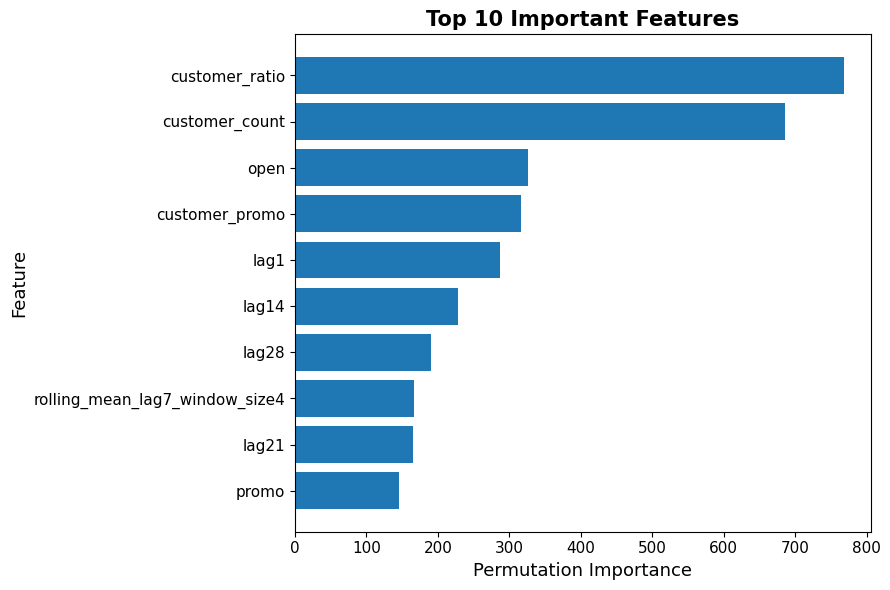

Permutation importance saved.


In [106]:
# ==========================================================
# Permutation Feature Importance
# ==========================================================

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# ==========================================================
# Generate Features from the Final Model
# ==========================================================

features = final_fcst.preprocess(

    sales,

    static_features=[]

)

print("=" * 60)
print("Generated Features")
print("=" * 60)

print(features.head())

print()

print("Feature Matrix Shape:")

print(features.shape)

# ==========================================================
# Create Evaluation Dataset
# ==========================================================

# Use the last 42 days for evaluation
eval_size = 42 * sales["unique_id"].nunique()

train_features = features.iloc[:-eval_size].copy()

test_features = features.iloc[-eval_size:].copy()

# Randomly sample observations to reduce computation time
test_features = test_features.sample(

    n=min(1000, len(test_features)),

    random_state=42

)

print("=" * 60)
print("Evaluation Dataset")
print("=" * 60)

print("Train Features:", train_features.shape)

print("Test Features :", test_features.shape)

# ==========================================================
# Prepare Test Data
# ==========================================================

X_test = test_features.drop(

    columns=[

        "unique_id",

        "ds",

        "y"

    ]

)

y_test = test_features["y"]

print()

print("X_test Shape:")

print(X_test.shape)

# ==========================================================
# Extract Final Random Forest
# ==========================================================

rf = list(final_fcst.models_.values())[0]

print("=" * 60)
print("Final Random Forest")
print("=" * 60)

print(rf)

# ==========================================================
# Permutation Importance
# ==========================================================

perm = permutation_importance(

    estimator=rf,

    X=X_test,

    y=y_test,

    scoring="neg_mean_absolute_error",

    n_repeats=2,

    random_state=42,

    n_jobs=1

)

print()

print("Permutation importance completed.")

# ==========================================================
# Create Importance Table
# ==========================================================

importance = pd.DataFrame({

    "Feature": X_test.columns,

    "Importance": perm.importances_mean

})

# ==========================================================
# Rename Feature for Visualization
# ==========================================================

importance["Feature"] = importance["Feature"].replace({

    "customer_prediction": "customer_count"

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

).reset_index(drop=True)

print("=" * 60)
print("Top 10 Important Features")
print("=" * 60)

print(importance.head(10))

# ==========================================================
# Plot Top 10 Features
# ==========================================================

top10 = importance.head(10)

plt.figure(

    figsize=(9, 6)

)

plt.barh(

    top10["Feature"],

    top10["Importance"]

)

plt.gca().invert_yaxis()

plt.xlabel(

    "Permutation Importance",

    fontsize=13

)

plt.ylabel(

    "Feature",

    fontsize=13

)

plt.title(

    "Top 10 Important Features",

    fontsize=15,

    fontweight="bold"

)

plt.xticks(

    fontsize=11

)

plt.yticks(

    fontsize=11

)

plt.tight_layout()

# ==========================================================
# Save Figure
# ==========================================================

plt.savefig(

    processed_dir / "permutation_feature_importance.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

# ==========================================================
# Save Results
# ==========================================================

importance.to_csv(

    processed_dir / "permutation_importance.csv",

    index=False

)

print("=" * 60)
print("Permutation importance saved.")
print("=" * 60)

In [107]:
# ==========================================================
# Predict Future 42 Days
# ==========================================================

future_forecast = final_fcst.predict(

    h=42,

    X_df=future

)

prediction_col = future_forecast.columns[-1]

future_forecast = future_forecast.rename(

    columns={
        prediction_col: "sales_prediction"
    }

)

print("=" * 60)
print("Future Forecast")
print("=" * 60)

print(future_forecast.head())

print()

print("Forecast Shape:")

print(future_forecast.shape)

# ==========================================================
# Create Final Forecast Dataset
# ==========================================================

future_result = future[
    [
        "unique_id",
        "ds",
        "customer_prediction"
    ]
].merge(

    future_forecast,

    on=[
        "unique_id",
        "ds"
    ],

    how="left"

)

print()

print("=" * 60)
print("Final Forecast")
print("=" * 60)

print(future_result.head())

# ==========================================================
# Keep Forecast Until 2015-08-29
# ==========================================================

future_result = future_result[
    future_result["ds"] < "2015-08-30"
].copy()

print("=" * 60)
print("Forecast Period")
print("=" * 60)

print(
    future_result["ds"].min(),
    "to",
    future_result["ds"].max()
)

print(f"Rows: {len(future_result):,}")

# ==========================================================
# Save Forecast
# ==========================================================

output_file = processed_dir / "future_prediction_rf.csv"

future_result.to_csv(
    output_file,
    index=False
)

print("=" * 60)
print("Forecast saved successfully.")
print("=" * 60)

print(output_file)

Future Forecast
  unique_id         ds  sales_prediction
0   store_1 2015-07-20          3727.445
1   store_1 2015-07-21          3443.395
2   store_1 2015-07-22          3508.745
3   store_1 2015-07-23          3577.855
4   store_1 2015-07-24          3617.725

Forecast Shape:
(28392, 3)

Final Forecast
  unique_id         ds  customer_prediction  sales_prediction
0   store_1 2015-07-20              486.060          3727.445
1   store_1 2015-07-21              446.065          3443.395
2   store_1 2015-07-22              461.360          3508.745
3   store_1 2015-07-23              470.705          3577.855
4   store_1 2015-07-24              462.035          3617.725
Forecast Period
2015-07-20 00:00:00 to 2015-08-29 00:00:00
Rows: 27,716
Forecast saved successfully.
data\processed\future_prediction_rf.csv


In [108]:
# ==========================================================
# Weekly Forecast Aggregation
# ==========================================================
# Aggregate every consecutive 7 days into one forecast week
# ==========================================================

weekly_data = future_result.copy()

# ----------------------------------------------------------
# Create Forecast Week
# ----------------------------------------------------------

weekly_data = weekly_data.sort_values(
    ["unique_id", "ds"]
).reset_index(drop=True)

weekly_data["forecast_week"] = (

        weekly_data

        .groupby("unique_id")

        .cumcount()

        // 7

        + 1

)

print("=" * 60)
print("Forecast Weeks")
print("=" * 60)

print(
    weekly_data[
        [
            "unique_id",
            "ds",
            "forecast_week"
        ]
    ].head(15)
)

# ==========================================================
# Store Weekly Forecast
# ==========================================================

store_weekly = (

    weekly_data

    .groupby(

        [
            "unique_id",
            "forecast_week"
        ],

        as_index=False

    )["sales_prediction"]

    .sum()

)

print("=" * 60)
print("Store Weekly Forecast")
print("=" * 60)

print(store_weekly.head())

# ==========================================================
# Merge Metadata
# ==========================================================

metadata_rf = metadata.rename(

    columns={

        "store_id": "unique_id"

    }

)

store_weekly = store_weekly.merge(

    metadata_rf[
        [
            "unique_id",
            "store_type"
        ]
    ],

    how="left",

    on="unique_id"

)

# ==========================================================
# Store Type Weekly Forecast
# ==========================================================

store_type_weekly = (

    store_weekly

    .groupby(

        [
            "store_type",
            "forecast_week"
        ],

        as_index=False

    )["sales_prediction"]

    .sum()

)

print("=" * 60)
print("Store Type Weekly Forecast")
print("=" * 60)

print(store_type_weekly)

# ==========================================================
# Company Weekly Forecast
# ==========================================================

company_weekly = (

    store_weekly

    .groupby(

        "forecast_week",

        as_index=False

    )["sales_prediction"]

    .sum()

)

print("=" * 60)
print("Company Weekly Forecast")
print("=" * 60)

print(company_weekly)

# ==========================================================
# Total Forecast for the Next 6 Weeks
# ==========================================================

company_total = company_weekly["sales_prediction"].sum()

print("=" * 60)
print("Total Sales Forecast")
print("=" * 60)

print(f"6-Week Total Sales: {company_total:,.2f}")

# ==========================================================
# COO Focus:
# First Two Weeks
# ==========================================================

print("=" * 60)
print("Forecast for the Next Two Weeks")
print("=" * 60)

print(company_weekly.head(2))

# ==========================================================
# Save Results
# ==========================================================

store_weekly.to_csv(
    processed_dir / "store_weekly_forecast_rf.csv",
    index=False
)

store_type_weekly.to_csv(
    processed_dir / "store_type_weekly_forecast_rf.csv",
    index=False
)

company_weekly.to_csv(
    processed_dir / "company_weekly_forecast_rf.csv",
    index=False
)

print("=" * 60)
print("Weekly forecasts saved successfully.")
print("=" * 60)

Forecast Weeks
   unique_id         ds  forecast_week
0    store_1 2015-07-20              1
1    store_1 2015-07-21              1
2    store_1 2015-07-22              1
3    store_1 2015-07-23              1
4    store_1 2015-07-24              1
5    store_1 2015-07-25              1
6    store_1 2015-07-26              1
7    store_1 2015-07-27              2
8    store_1 2015-07-28              2
9    store_1 2015-07-29              2
10   store_1 2015-07-30              2
11   store_1 2015-07-31              2
12   store_1 2015-08-01              2
13   store_1 2015-08-02              2
14   store_1 2015-08-03              3
Store Weekly Forecast
  unique_id  forecast_week  sales_prediction
0   store_1              1         21681.355
1   store_1              2         28624.885
2   store_1              3         27145.375
3   store_1              4         21828.790
4   store_1              5         26256.375
Store Type Weekly Forecast
   store_type  forecast_week  sales_predic

Cross Validation Predictions
  unique_id         ds      cutoff     y  RandomForestRegressor
0   store_1 2015-03-16  2015-03-15  5695               5547.920
1   store_1 2015-03-17  2015-03-15  4806               4924.320
2   store_1 2015-03-18  2015-03-15  3858               4562.565
3   store_1 2015-03-19  2015-03-15  4748               4395.230
4   store_1 2015-03-20  2015-03-15  4057               4474.575
Merged Store Type
  unique_id         ds      cutoff     y  RandomForestRegressor  store_type
0   store_1 2015-03-16  2015-03-15  5695               5547.920           2
1   store_1 2015-03-17  2015-03-15  4806               4924.320           2
2   store_1 2015-03-18  2015-03-15  3858               4562.565           2
3   store_1 2015-03-19  2015-03-15  4748               4395.230           2
4   store_1 2015-03-20  2015-03-15  4057               4474.575           2
Prediction column: RandomForestRegressor
Forecast Accuracy
   store_type       MAPE  Samples Store Type
0        

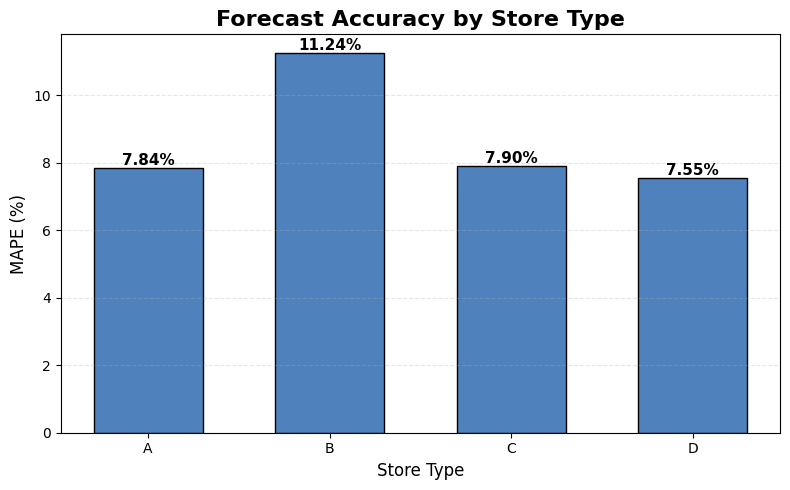

In [109]:
#Where does the model perform poorly
# ==========================================================
# Forecast Accuracy by Store Type
# ==========================================================
# ==========================================================
# Forecast Accuracy by Store Type
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# Load Cross Validation Predictions
# ==========================================================

cv = pd.read_csv(
    processed_dir / "rf_best_cv_predictions.csv",
    parse_dates=["ds"]
)

print("=" * 60)
print("Cross Validation Predictions")
print("=" * 60)

print(cv.head())

# ==========================================================
# Merge Store Type Information
# ==========================================================

store_info = (

    sales[
        [
            "unique_id",
            "store_type"
        ]
    ]

    .drop_duplicates()

)

cv = cv.merge(

    store_info,

    on="unique_id",

    how="left"

)

print("=" * 60)
print("Merged Store Type")
print("=" * 60)

print(cv.head())

# ==========================================================
# Prediction Column
# ==========================================================

prediction_col = cv.columns[-2]

print(f"Prediction column: {prediction_col}")

# ==========================================================
# Remove Zero Sales
# ==========================================================

cv = cv.loc[
    cv["y"] > 0
    ].copy()

# ==========================================================
# Absolute Percentage Error
# ==========================================================

cv["APE"] = (

                    np.abs(

                        cv["y"] -
                        cv[prediction_col]

                    )

                    /

                    cv["y"]

            ) * 100

# ==========================================================
# Forecast Accuracy by Store Type
# ==========================================================

accuracy = (

    cv

    .groupby(
        "store_type",
        as_index=False
    )

    .agg(

        MAPE=(
            "APE",
            "mean"
        ),

        Samples=(
            "APE",
            "count"
        )

    )

)

# ==========================================================
# Convert Store Labels
# ==========================================================

store_labels = {

    0: "A",
    1: "B",
    2: "C",
    3: "D"

}

accuracy["Store Type"] = (

    accuracy["store_type"]

    .map(store_labels)

)

accuracy = accuracy.sort_values(
    "Store Type"
)

print("=" * 60)
print("Forecast Accuracy")
print("=" * 60)

print(accuracy)

# ==========================================================
# Save Results
# ==========================================================

accuracy.to_csv(

    processed_dir /
    "forecast_accuracy_store_type.csv",

    index=False

)

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(8, 5))

bars = plt.bar(

    accuracy["Store Type"],

    accuracy["MAPE"],

    color="#4F81BD",

    edgecolor="black",

    width=0.6

)

for bar in bars:
    height = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width() / 2,

        height + 0.1,

        f"{height:.2f}%",

        ha="center",

        fontsize=11,

        fontweight="bold"

    )

plt.title(

    "Forecast Accuracy by Store Type",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel(

    "Store Type",

    fontsize=12

)

plt.ylabel(

    "MAPE (%)",

    fontsize=12

)

plt.grid(

    axis="y",

    linestyle="--",

    alpha=0.3

)

plt.tight_layout()

plt.savefig(

    processed_dir /
    "forecast_accuracy_store_type.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

In [110]:
# ==========================================================
# Forecast Accuracy by Promotion
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Load Cross Validation Predictions
# ----------------------------------------------------------

print("=" * 60)
print("Cross Validation Predictions")
print("=" * 60)

print(cv.head())

# ----------------------------------------------------------
# Merge Promotion Information
# ----------------------------------------------------------

promo_info = sales[
    [
        "unique_id",
        "ds",
        "promo"
    ]
].copy()

promo_info["ds"] = pd.to_datetime(promo_info["ds"])
cv["ds"] = pd.to_datetime(cv["ds"])

cv = cv.merge(

    promo_info,

    on=[
        "unique_id",
        "ds"
    ],

    how="left"

)

print("=" * 60)
print("Merged Promotion")
print("=" * 60)

print(cv.head())

# ----------------------------------------------------------
# Prediction Column
# ----------------------------------------------------------

prediction_col = "RandomForestRegressor"

print(f"Prediction column: {prediction_col}")

# ----------------------------------------------------------
# Remove Zero Sales
# ----------------------------------------------------------

cv = cv[

    cv["y"] > 0

    ].copy()

# ----------------------------------------------------------
# Calculate Absolute Percentage Error
# ----------------------------------------------------------

cv["APE"] = (

                    np.abs(

                        cv["y"] -

                        cv[prediction_col]

                    )

                    / cv["y"]

            ) * 100

# ----------------------------------------------------------
# Average MAPE
# ----------------------------------------------------------

promo_result = (

    cv

    .groupby("promo")

    .agg(

        MAPE=("APE", "mean"),

        Samples=("APE", "count")

    )

    .reset_index()

)

promo_result["Scenario"] = (

    promo_result["promo"]

    .map({

        0: "Non-Promo",

        1: "Promotion"

    })

)

print("=" * 60)
print("Forecast Accuracy")
print("=" * 60)

print(promo_result)

promo_result.to_csv(

    processed_dir / "forecast_accuracy_promo.csv",

    index=False

)



Cross Validation Predictions
  unique_id         ds      cutoff     y  RandomForestRegressor  store_type  \
0   store_1 2015-03-16  2015-03-15  5695               5547.920           2   
1   store_1 2015-03-17  2015-03-15  4806               4924.320           2   
2   store_1 2015-03-18  2015-03-15  3858               4562.565           2   
3   store_1 2015-03-19  2015-03-15  4748               4395.230           2   
4   store_1 2015-03-20  2015-03-15  4057               4474.575           2   

         APE  
0   2.582616  
1   2.461923  
2  18.262442  
3   7.429865  
4  10.292704  
Merged Promotion
  unique_id         ds      cutoff     y  RandomForestRegressor  store_type  \
0   store_1 2015-03-16  2015-03-15  5695               5547.920           2   
1   store_1 2015-03-17  2015-03-15  4806               4924.320           2   
2   store_1 2015-03-18  2015-03-15  3858               4562.565           2   
3   store_1 2015-03-19  2015-03-15  4748               4395.230          

Store Sales Groups
   unique_id    avg_sales Sales Group
0    store_1  3948.138528         Low
1   store_10  5557.781385      Medium
2  store_100  4820.503247      Medium
3  store_101  4372.957792         Low
4  store_102  6040.603896      Medium
Merged Sales Group
  unique_id         ds      cutoff     y  RandomForestRegressor  store_type  \
0   store_1 2015-03-16  2015-03-15  5695               5547.920           2   
1   store_1 2015-03-17  2015-03-15  4806               4924.320           2   
2   store_1 2015-03-18  2015-03-15  3858               4562.565           2   
3   store_1 2015-03-19  2015-03-15  4748               4395.230           2   
4   store_1 2015-03-20  2015-03-15  4057               4474.575           2   

         APE  promo Sales Group  
0   2.582616      1         Low  
1   2.461923      1         Low  
2  18.262442      1         Low  
3   7.429865      1         Low  
4  10.292704      1         Low  
Forecast Accuracy by Sales Volume
  Sales Group      MA

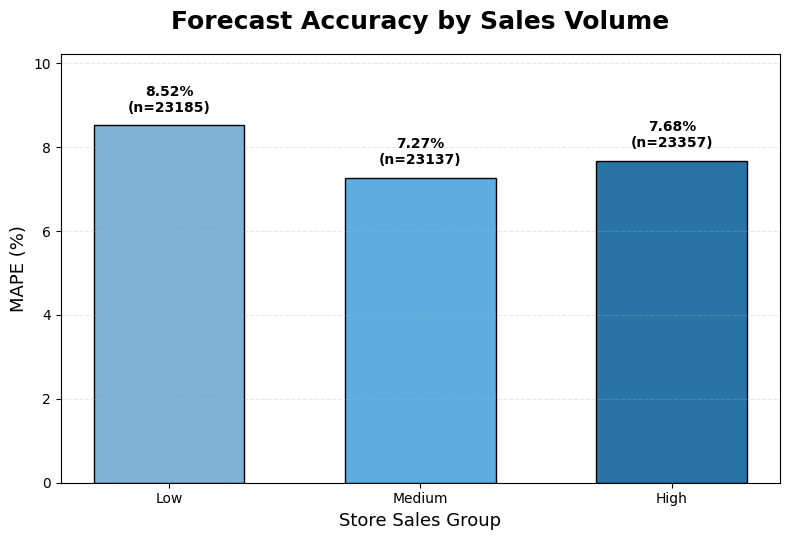

In [111]:
# ==========================================================
# Forecast Accuracy by Sales Volume
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Average Historical Sales of Each Store
# ----------------------------------------------------------

store_volume = (

    sales

    .groupby("unique_id")["y"]

    .mean()

    .reset_index()

    .rename(columns={"y": "avg_sales"})

)

# ----------------------------------------------------------
# Divide into Low / Medium / High
# ----------------------------------------------------------

store_volume["Sales Group"] = pd.qcut(

    store_volume["avg_sales"],

    q=3,

    labels=[

        "Low",

        "Medium",

        "High"

    ]

)

print("=" * 60)
print("Store Sales Groups")
print("=" * 60)

print(store_volume.head())

# ----------------------------------------------------------
# Create a Clean Copy of CV
# ----------------------------------------------------------

cv_volume = cv.copy()

# Remove columns from previous analyses if they exist
cv_volume = cv_volume.drop(

    columns=[
        "Sales Group",
        "Sales Group_x",
        "Sales Group_y"
    ],

    errors="ignore"

)

# ----------------------------------------------------------
# Merge Sales Groups
# ----------------------------------------------------------

cv_volume = cv_volume.merge(

    store_volume[
        [
            "unique_id",
            "Sales Group"
        ]
    ],

    on="unique_id",

    how="left"

)

print("=" * 60)
print("Merged Sales Group")
print("=" * 60)

print(cv_volume.head())

# ----------------------------------------------------------
# Prediction Column
# ----------------------------------------------------------

prediction_col = "RandomForestRegressor"

# ----------------------------------------------------------
# Remove Zero Sales
# ----------------------------------------------------------

cv_volume = cv_volume[

    cv_volume["y"] > 0

    ].copy()

# ----------------------------------------------------------
# Calculate Absolute Percentage Error
# ----------------------------------------------------------

cv_volume["APE"] = (

                           np.abs(

                               cv_volume["y"]

                               -

                               cv_volume[prediction_col]

                           )

                           /

                           cv_volume["y"]

                   ) * 100

# ----------------------------------------------------------
# Average MAPE by Sales Group
# ----------------------------------------------------------

volume_result = (

    cv_volume

    .groupby("Sales Group", observed=True)

    .agg(

        MAPE=("APE", "mean"),

        Samples=("APE", "count"),

        Average_Sales=("y", "mean")

    )

    .reset_index()

)

print("=" * 60)
print("Forecast Accuracy by Sales Volume")
print("=" * 60)

print(volume_result)

volume_result.to_csv(

    processed_dir /

    "forecast_accuracy_sales_volume.csv",

    index=False

)

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(8, 5.5))

bars = plt.bar(

    volume_result["Sales Group"],

    volume_result["MAPE"],

    color=[

        "#7FB3D5",

        "#5DADE2",

        "#2874A6"

    ],

    edgecolor="black",

    width=0.60

)

plt.title(

    "Forecast Accuracy by Sales Volume",

    fontsize=18,

    fontweight="bold",

    pad=18

)

plt.ylabel(

    "MAPE (%)",

    fontsize=13

)

plt.xlabel(

    "Store Sales Group",

    fontsize=13

)

plt.grid(

    axis="y",

    linestyle="--",

    alpha=0.3

)

# ----------------------------------------------------------
# Leave Space for Labels
# ----------------------------------------------------------

upper = volume_result["MAPE"].max() * 1.20

plt.ylim(

    0,

    upper

)

offset = volume_result["MAPE"].max() * 0.03

# ----------------------------------------------------------
# Labels
# ----------------------------------------------------------

for bar, value, n in zip(

        bars,

        volume_result["MAPE"],

        volume_result["Samples"]

):
    plt.text(

        bar.get_x() + bar.get_width() / 2,

        value + offset,

        f"{value:.2f}%\n(n={n})",

        ha="center",

        va="bottom",

        fontsize=10,

        fontweight="bold"

    )

plt.tight_layout()

plt.savefig(

    processed_dir /

    "forecast_accuracy_sales_volume.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

Forecast Horizons
count    69679.000000
mean        21.012916
std         12.177760
min          1.000000
25%         10.000000
50%         22.000000
75%         32.000000
max         42.000000
Name: Horizon, dtype: float64
Forecast Accuracy by Horizon
  Forecast Week      MAPE  Samples
0        Week 1  6.622818    11573
1        Week 2  6.375420    12240
2        Week 3  9.046341    10931
3        Week 4  7.618532    11594
4        Week 5  8.677122    11596
5        Week 6  8.729522    11745


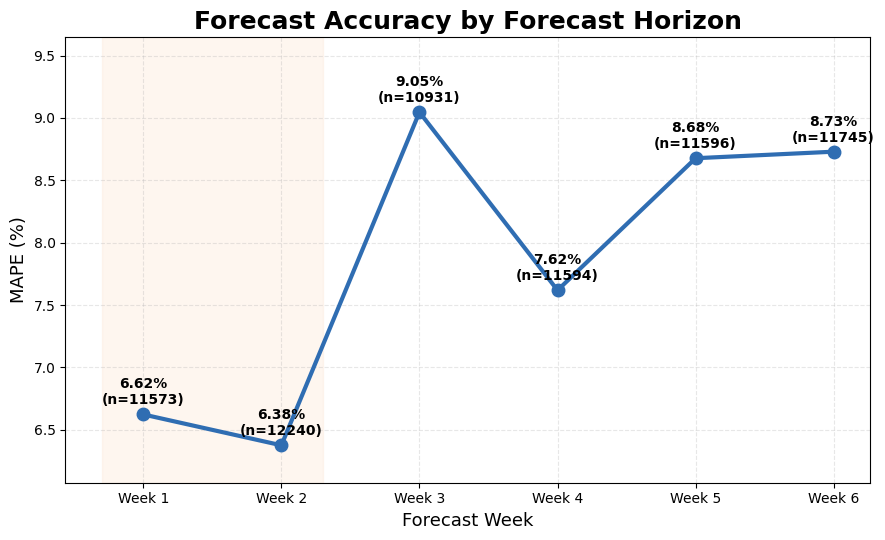

In [112]:
# ==========================================================
# Forecast Accuracy by Forecast Horizon
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Copy Cross Validation Results
# ----------------------------------------------------------

cv_horizon = cv.copy()

prediction_col = "RandomForestRegressor"

# ----------------------------------------------------------
# Remove Zero Sales
# ----------------------------------------------------------

cv_horizon = cv_horizon[
    cv_horizon["y"] > 0
    ].copy()

# ----------------------------------------------------------
# Absolute Percentage Error
# ----------------------------------------------------------

cv_horizon["APE"] = (
                            np.abs(
                                cv_horizon["y"] -
                                cv_horizon[prediction_col]
                            )
                            /
                            cv_horizon["y"]
                    ) * 100

# ----------------------------------------------------------
# Forecast Horizon
# ----------------------------------------------------------

cv_horizon["cutoff"] = pd.to_datetime(cv_horizon["cutoff"])
cv_horizon["ds"] = pd.to_datetime(cv_horizon["ds"])

cv_horizon["Horizon"] = (
        cv_horizon["ds"] -
        cv_horizon["cutoff"]
).dt.days

print("=" * 60)
print("Forecast Horizons")
print("=" * 60)
print(cv_horizon["Horizon"].describe())

# ----------------------------------------------------------
# Weekly Horizon Groups
# ----------------------------------------------------------

bins = [0, 7, 14, 21, 28, 35, 42]

labels = [
    "Week 1",
    "Week 2",
    "Week 3",
    "Week 4",
    "Week 5",
    "Week 6"
]

cv_horizon["Forecast Week"] = pd.cut(

    cv_horizon["Horizon"],

    bins=bins,

    labels=labels,

    include_lowest=True

)

# ----------------------------------------------------------
# Average MAPE
# ----------------------------------------------------------

horizon_result = (

    cv_horizon

    .groupby(
        "Forecast Week",
        observed=True
    )

    .agg(

        MAPE=("APE", "mean"),

        Samples=("APE", "count")

    )

    .reset_index()

)

print("=" * 60)
print("Forecast Accuracy by Horizon")
print("=" * 60)

print(horizon_result)

horizon_result.to_csv(

    processed_dir /

    "forecast_accuracy_horizon.csv",

    index=False

)

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(9, 5.5))

plt.plot(

    horizon_result["Forecast Week"],

    horizon_result["MAPE"],

    marker="o",

    linewidth=3,

    markersize=9,

    color="#2F6DB2"

)

plt.grid(

    linestyle="--",

    alpha=0.3

)

plt.title(

    "Forecast Accuracy by Forecast Horizon",

    fontsize=18,

    fontweight="bold"

)
plt.axvspan(-0.3, 1.3,
            color="#FDE9D9",
            alpha=0.4,
            label="COO Focus")

plt.xlabel(

    "Forecast Week",

    fontsize=13

)

plt.ylabel(

    "MAPE (%)",

    fontsize=13

)

plt.ylim(

    horizon_result["MAPE"].min() - 0.3,

    horizon_result["MAPE"].max() + 0.6

)

offset = 0.08

for x, y, n in zip(

        horizon_result["Forecast Week"],

        horizon_result["MAPE"],

        horizon_result["Samples"]

):
    plt.text(

        x,

        y + offset,

        f"{y:.2f}%\n(n={n})",

        ha="center",

        fontsize=10,

        fontweight="bold"

    )

plt.tight_layout()

plt.savefig(

    processed_dir /

    "forecast_accuracy_horizon.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

In [113]:
# ==========================================================
# Company Historical Sales
# ==========================================================

company_history = (

    sales
    .groupby("ds", as_index=False)["y"]
    .sum()

)

company_history["unique_id"] = "Company"

company_history = company_history[
    ["unique_id", "ds", "y"]
]

# Keep only the last 42 historical days
company_history = company_history.tail(42)

# ==========================================================
# Company Forecast
# ==========================================================

company_forecast = (

    future_result
    .groupby("ds", as_index=False)["sales_prediction"]
    .sum()

)

company_forecast["unique_id"] = "Company"

company_forecast = company_forecast.rename(
    columns={
        "sales_prediction": "RandomForest"
    }
)

company_forecast = company_forecast[
    ["unique_id", "ds", "RandomForest"]
]

# ==========================================================
# Plot
# ==========================================================
fig = StatsForecast.plot(

    df=company_history,

    forecasts_df=company_forecast

)

fig.savefig(

    processed_dir / "company_forecast.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

Daily Company Forecast
          ds  sales_prediction
0 2015-07-20       4041089.635
1 2015-07-21       3731512.040
2 2015-07-22       3719440.870
3 2015-07-23       3846851.130
4 2015-07-24       3958989.580
(41, 2)
Weekly Forecast
   sales_prediction  week  Sales_Million
0      2.323569e+07     1      23.235695
1      3.178106e+07     2      31.781063
2      3.080133e+07     3      30.801326
3      2.426294e+07     4      24.262941
4      3.071198e+07     5      30.711976
5      2.414014e+07     6      24.140136


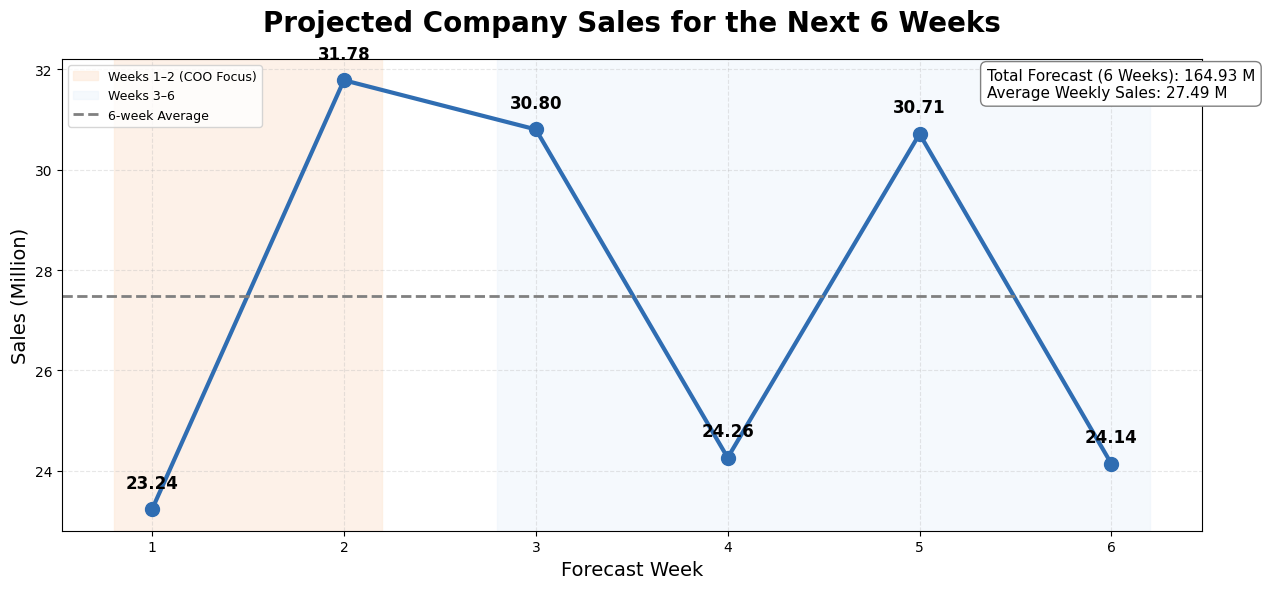

In [114]:
# ==========================================================
# Company Weekly Forecast
# ==========================================================

import numpy as np
import pandas as pd

# ----------------------------------------------------------
# Daily Company Forecast
# ----------------------------------------------------------

daily_company = (

    future_result

    .groupby(
        "ds",
        as_index=False
    )["sales_prediction"]

    .sum()

)

print("=" * 60)
print("Daily Company Forecast")
print("=" * 60)

print(daily_company.head())

print(daily_company.shape)

# ----------------------------------------------------------
# Weekly Forecast
# ----------------------------------------------------------

weekly_forecast = (

    daily_company

    .groupby(

        np.arange(len(daily_company)) // 7,

        as_index=False

    )["sales_prediction"]

    .sum()

)

weekly_forecast["week"] = np.arange(1, 7)

weekly_forecast["Sales_Million"] = (

    weekly_forecast["sales_prediction"] / 1_000_000

)

print("=" * 60)
print("Weekly Forecast")
print("=" * 60)

print(weekly_forecast)

# ----------------------------------------------------------
# Save
# ----------------------------------------------------------

weekly_forecast.to_csv(

    processed_dir / "weekly_forecast_rf.csv",

    index=False

)

# ==========================================================
# Weekly Forecast Dashboard
# ==========================================================

import matplotlib.pyplot as plt

weekly_sales = weekly_forecast["Sales_Million"]

weeks = weekly_forecast["week"]

total_sales = weekly_sales.sum()

average_sales = weekly_sales.mean()

fig, ax = plt.subplots(
    figsize=(13,6)
)

# ----------------------------------------------------------
# Background
# ----------------------------------------------------------

ax.axvspan(
    0.8,
    2.2,
    color="#FDE9D9",
    alpha=0.6,
    label="Weeks 1–2 (COO Focus)"
)

ax.axvspan(
    2.8,
    6.2,
    color="#EAF2FB",
    alpha=0.45,
    label="Weeks 3–6"
)

# ----------------------------------------------------------
# Forecast Line
# ----------------------------------------------------------

ax.plot(
    weeks,
    weekly_sales,
    color="#2F6DB2",
    linewidth=3,
    marker="o",
    markersize=10
)

# ----------------------------------------------------------
# Average Line
# ----------------------------------------------------------

ax.axhline(
    average_sales,
    color="gray",
    linestyle="--",
    linewidth=2,
    label="6-week Average"
)

# ----------------------------------------------------------
# Labels
# ----------------------------------------------------------

offset = (
    weekly_sales.max()
    - weekly_sales.min()
) * 0.05

for x, y in zip(weeks, weekly_sales):

    ax.text(
        x,
        y + offset,
        f"{y:.2f}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

# ----------------------------------------------------------
# Statistics Box
# ----------------------------------------------------------

stats = (
    f"Total Forecast (6 Weeks): {total_sales:.2f} M\n"
    f"Average Weekly Sales: {average_sales:.2f} M"
)

ax.text(
    5.35,
    weekly_sales.max() + 0.25,
    stats,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        boxstyle="round,pad=0.4"
    )
)

# ----------------------------------------------------------
# Layout
# ----------------------------------------------------------

ax.set_title(
    "Projected Company Sales for the Next 6 Weeks",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Forecast Week",
    fontsize=14
)

ax.set_ylabel(
    "Sales (Million)",
    fontsize=14
)

ax.set_xticks(weeks)

ax.grid(
    alpha=0.3,
    linestyle="--"
)

ax.legend(
    loc="upper left",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    processed_dir / "kpi_total_sales_6weeks.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [115]:
# ==========================================================
# Top 5 Stores Forecast (Next 2 Weeks)
# ==========================================================

# ----------------------------------------------------------
# First 14 Forecast Days
# ----------------------------------------------------------

start_date = future_result["ds"].min()

end_date = start_date + pd.Timedelta(days=13)

future_14 = future_result[

    (future_result["ds"] >= start_date) &
    (future_result["ds"] <= end_date)

    ].copy()

# ----------------------------------------------------------
# Find Top 5 Stores (Next 2 Weeks)
# ----------------------------------------------------------

top5_stores = (

    future_14

    .groupby(
        "unique_id",
        as_index=False
    )["sales_prediction"]

    .sum()

    .sort_values(
        "sales_prediction",
        ascending=False
    )

    .head(5)

)

print("=" * 60)
print("Top 5 Stores (Next 2 Weeks)")
print("=" * 60)

print(top5_stores)

# ----------------------------------------------------------
# Historical Data
# ----------------------------------------------------------

history_top5 = (

    sales

    .merge(

        top5_stores[
            ["unique_id"]
        ],

        on="unique_id"

    )

)

history_top5 = history_top5[
    [
        "unique_id",
        "ds",
        "y"
    ]
]

# Keep only the last 42 historical days

history_top5 = (

    history_top5

    .sort_values(
        [
            "unique_id",
            "ds"
        ]
    )

    .groupby("unique_id")

    .tail(42)

)

# ----------------------------------------------------------
# Forecast Data (Next 2 Weeks Only)
# ----------------------------------------------------------

forecast_top5 = (

    future_14

    .merge(

        top5_stores[
            ["unique_id"]
        ],

        on="unique_id"

    )

)

forecast_top5 = forecast_top5.rename(

    columns={

        "sales_prediction": "RandomForest"

    }

)

forecast_top5 = forecast_top5[
    [
        "unique_id",
        "ds",
        "RandomForest"
    ]
]

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

import matplotlib.pyplot as plt

fig = StatsForecast.plot(

    df=history_top5,

    forecasts_df=forecast_top5

)

# ----------------------------------------------------------
# Improve Title
# ----------------------------------------------------------

fig.suptitle(

    "Top 5 Store Sales Forecast (Next 2 Weeks)",

    fontsize=18,

    fontweight="bold",

    y=1.02

)

# ----------------------------------------------------------
# Save
# ----------------------------------------------------------

fig.savefig(

    processed_dir / "top5_store_forecast_2weeks.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

Top 5 Stores (Next 2 Weeks)
     unique_id  sales_prediction
63   store_156        286763.775
639  store_675        260361.700
271  store_343        245525.710
55   store_149        205361.155
383  store_444        205013.500


Top 5 Stores
     unique_id  sales_prediction
63   store_156        832069.045
639  store_675        772986.305
271  store_343        716230.175
55   store_149        621039.050
383  store_444        602386.365


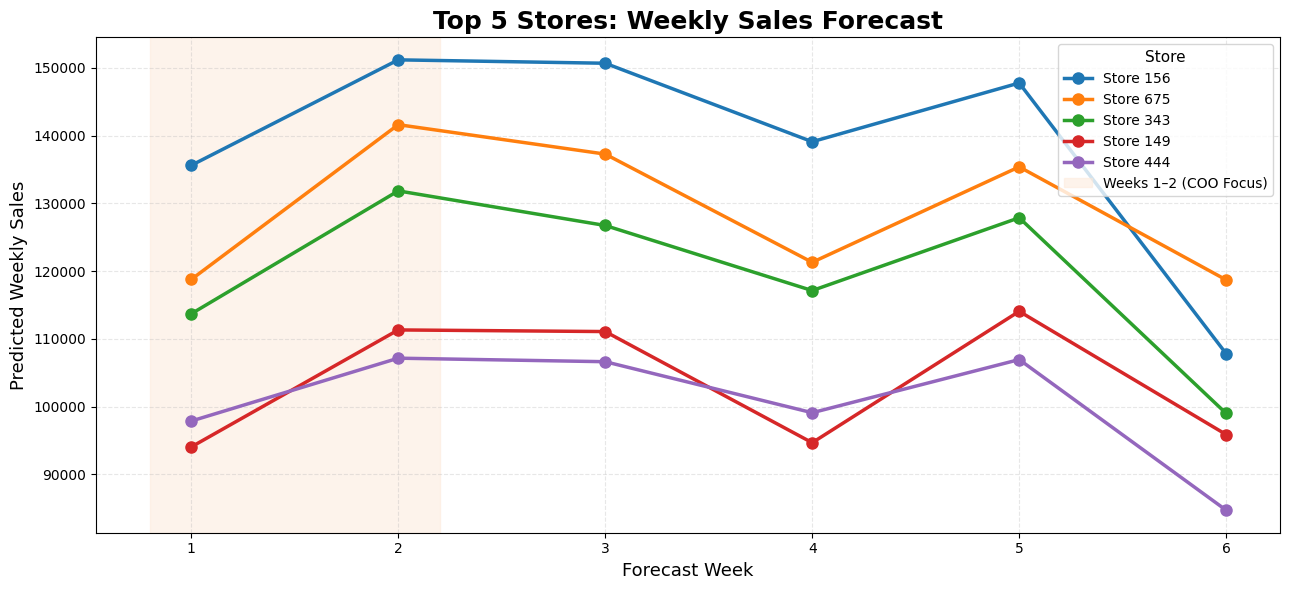

In [116]:
# ==========================================================
# Top 5 Stores Weekly Forecast
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Find Top 5 Stores
# ----------------------------------------------------------

top5_stores = (

    store_weekly

    .groupby(
        "unique_id",
        as_index=False
    )["sales_prediction"]

    .sum()

    .sort_values(
        "sales_prediction",
        ascending=False
    )

    .head(5)

)

print("=" * 60)
print("Top 5 Stores")
print("=" * 60)

print(top5_stores)

# ----------------------------------------------------------
# Weekly Forecast for Top 5 Stores
# ----------------------------------------------------------

top5_weekly = (

    store_weekly

    .merge(

        top5_stores[
            ["unique_id"]
        ],

        on="unique_id"

    )

)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(13, 6))

for store in top5_stores["unique_id"]:
    temp = (

        top5_weekly

        .loc[
            top5_weekly["unique_id"] == store
            ]

        .sort_values("forecast_week")

    )

    plt.plot(

        temp["forecast_week"],

        temp["sales_prediction"],

        marker="o",

        linewidth=2.5,

        markersize=8,

        label=store.replace("store_", "Store ")

    )

# ----------------------------------------------------------
# Highlight COO Focus
# ----------------------------------------------------------

plt.axvspan(

    0.8,

    2.2,

    color="#FDE9D9",

    alpha=0.5,

    label="Weeks 1–2 (COO Focus)"

)

# ----------------------------------------------------------
# Layout
# ----------------------------------------------------------

plt.title(

    "Top 5 Stores: Weekly Sales Forecast",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel(

    "Forecast Week",

    fontsize=13

)

plt.ylabel(

    "Predicted Weekly Sales",

    fontsize=13

)

plt.xticks(range(1, 7))

plt.grid(

    linestyle="--",

    alpha=0.3

)

plt.legend(

    title="Store",

    fontsize=10,

    title_fontsize=11,

    loc="upper right"

)

plt.tight_layout()

# ----------------------------------------------------------
# Save
# ----------------------------------------------------------

plt.savefig(

    processed_dir / "top5_store_weekly_forecast.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

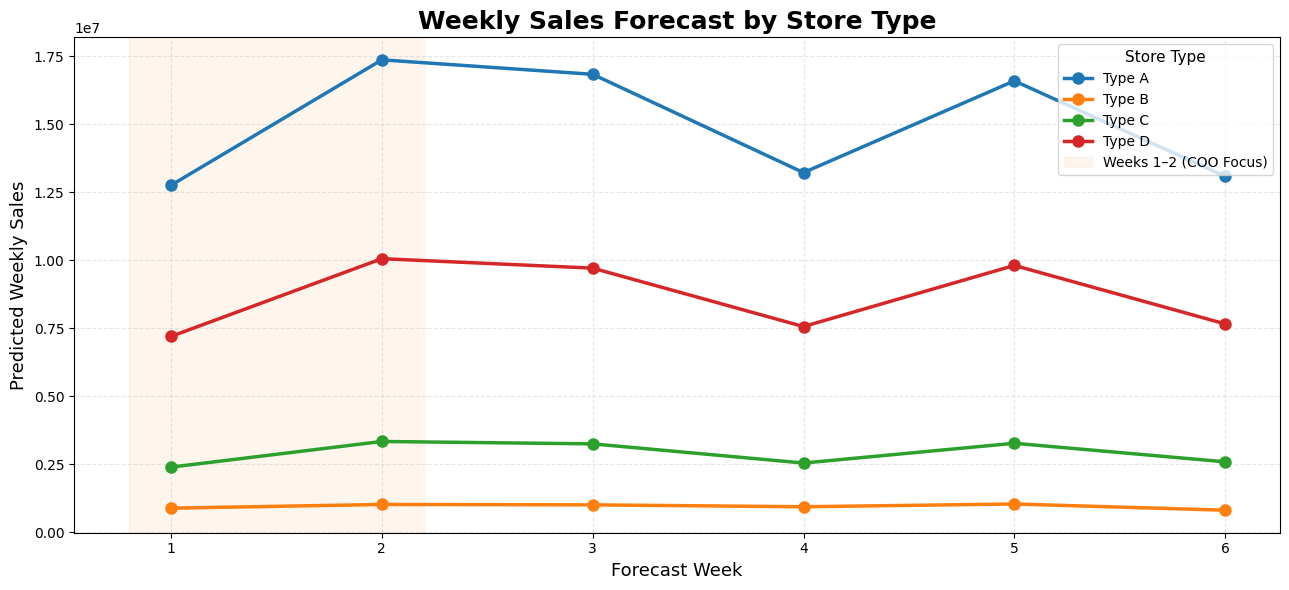

In [117]:
# ==========================================================
# Store Type Weekly Forecast
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(13, 6))

store_types = sorted(
    store_type_weekly["store_type"].unique()
)

for store_type in store_types:
    temp = (

        store_type_weekly

        .loc[
            store_type_weekly["store_type"] == store_type
            ]

        .sort_values("forecast_week")

    )

    plt.plot(

        temp["forecast_week"],

        temp["sales_prediction"],

        marker="o",

        linewidth=2.5,

        markersize=8,

        label=f"Type {store_type.upper()}"

    )

# ----------------------------------------------------------
# COO Highlight
# ----------------------------------------------------------

plt.axvspan(

    0.8,

    2.2,

    color="#FDE9D9",

    alpha=0.45,

    label="Weeks 1–2 (COO Focus)"

)

# ----------------------------------------------------------
# Layout
# ----------------------------------------------------------

plt.title(

    "Weekly Sales Forecast by Store Type",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel(

    "Forecast Week",

    fontsize=13

)

plt.ylabel(

    "Predicted Weekly Sales",

    fontsize=13

)

plt.xticks(range(1, 7))

plt.grid(

    linestyle="--",

    alpha=0.3

)

plt.legend(

    title="Store Type",

    fontsize=10,

    title_fontsize=11,

    loc="upper right"

)

plt.tight_layout()

# ----------------------------------------------------------
# Save
# ----------------------------------------------------------

plt.savefig(

    processed_dir / "store_type_weekly_forecast.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

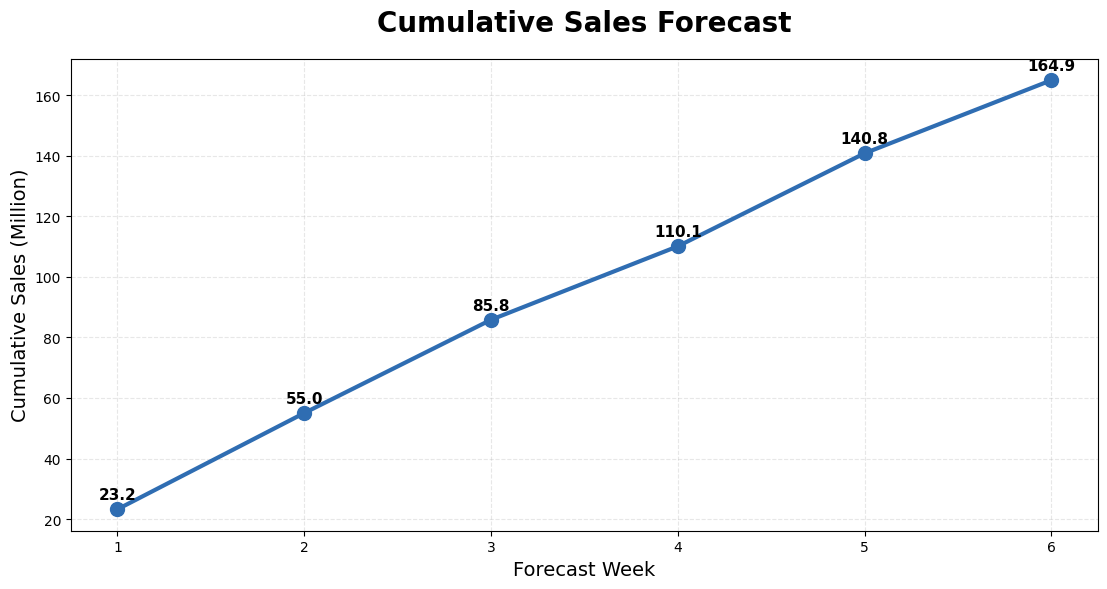

In [119]:
# ==========================================================
# Cumulative Sales Forecast
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Prepare Data
# ----------------------------------------------------------

cumulative_sales = company_weekly.copy()

cumulative_sales["cumulative_sales"] = (

    cumulative_sales["sales_prediction"]

    .cumsum()

)

cumulative_sales["Sales_Million"] = (

        cumulative_sales["cumulative_sales"]

        / 1_000_000

)

weeks = cumulative_sales["forecast_week"]

sales = cumulative_sales["Sales_Million"]

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

fig, ax = plt.subplots(

    figsize=(13, 6)

)

ax.plot(

    weeks,

    sales,

    color="#2F6DB2",

    linewidth=3,

    marker="o",

    markersize=10

)

# ----------------------------------------------------------
# Value Labels
# ----------------------------------------------------------

offset = sales.max() * 0.02

for x, y in zip(weeks, sales):
    ax.text(

        x,

        y + offset,

        f"{y:.1f}",

        ha="center",

        fontsize=11,

        fontweight="bold"

    )

# ----------------------------------------------------------
# Layout
# ----------------------------------------------------------

ax.set_title(

    "Cumulative Sales Forecast",

    fontsize=20,

    fontweight="bold",

    pad=20

)

ax.set_xlabel(

    "Forecast Week",

    fontsize=14

)

ax.set_ylabel(

    "Cumulative Sales (Million)",

    fontsize=14

)

ax.set_xticks(range(1, 7))

ax.grid(

    linestyle="--",

    alpha=0.3

)

# ----------------------------------------------------------
# KPI Outside Figure
# ----------------------------------------------------------



plt.tight_layout(

    rect=[0, 0, 0.86, 1]

)

# ----------------------------------------------------------
# Save
# ----------------------------------------------------------

plt.savefig(

    processed_dir / "cumulative_sales_forecast.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

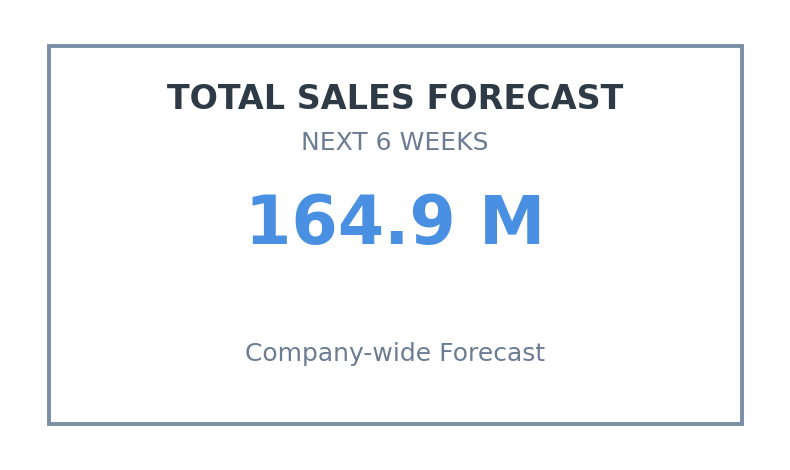

In [120]:
# ==========================================================
# KPI Card
# Total Sales Forecast (Next 6 Weeks)
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# KPI
# ----------------------------------------------------------

total_sales = company_weekly["sales_prediction"].sum() / 1_000_000

# ----------------------------------------------------------
# Card
# ----------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 4.8)
)

ax.axis("off")

# Border
card = plt.Rectangle(
    (0.05, 0.08),
    0.90,
    0.84,
    fill=False,
    linewidth=2.8,
    edgecolor="#7A8FA6"      # 柔和灰蓝
)

ax.add_patch(card)

# ----------------------------------------------------------
# Title
# ----------------------------------------------------------

ax.text(

    0.5,

    0.78,

    "TOTAL SALES FORECAST",

    ha="center",

    fontsize=24,

    fontweight="bold",

    color="#2E3A46"

)

ax.text(

    0.5,

    0.69,

    "NEXT 6 WEEKS",

    ha="center",

    fontsize=18,

    color="#6B7C93"

)

# ----------------------------------------------------------
# KPI Number
# ----------------------------------------------------------

ax.text(

    0.5,

    0.48,

    f"{total_sales:.1f} M",

    ha="center",

    fontsize=48,

    fontweight="bold",

    color="#4A90E2"

)

# ----------------------------------------------------------
# Subtitle
# ----------------------------------------------------------

ax.text(

    0.5,

    0.22,

    "Company-wide Forecast",

    ha="center",

    fontsize=18,

    color="#6B7C93"

)

plt.tight_layout()

plt.savefig(

    processed_dir / "weekly_forecast_dashboard.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

Forecast Period
2015-07-20 00:00:00
2015-08-02 00:00:00


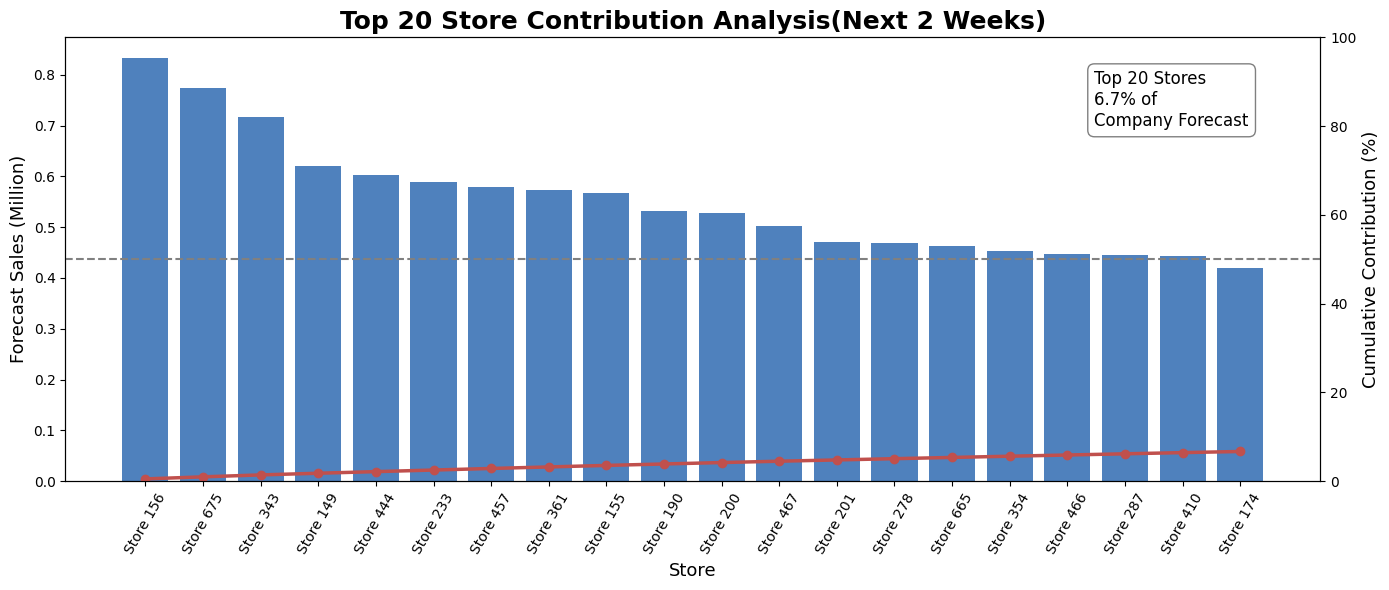

In [121]:
# ==========================================================
# Top 20 Store Contribution Analysis
# ==========================================================

import matplotlib.pyplot as plt
# ----------------------------------------------------------
# First 14 Forecast Days
# ----------------------------------------------------------

start_date = future_result["ds"].min()

end_date = start_date + pd.Timedelta(days=13)

future_14 = future_result[

    (future_result["ds"] >= start_date) &
    (future_result["ds"] <= end_date)

].copy()

print("=" * 60)
print("Forecast Period")
print("=" * 60)
print(start_date)
print(end_date)

# ----------------------------------------------------------
# Aggregate Forecast by Store
# ----------------------------------------------------------

pareto = (

    future_result

    .groupby(
        "unique_id",
        as_index=False
    )["sales_prediction"]

    .sum()

    .sort_values(
        "sales_prediction",
        ascending=False
    )

)

# ----------------------------------------------------------
# Company Total Forecast
# ----------------------------------------------------------

company_total = pareto["sales_prediction"].sum()

# ----------------------------------------------------------
# Top 20 Stores
# ----------------------------------------------------------

top_n = 20

pareto = pareto.head(top_n).copy()


pareto["label"] = (

    pareto["unique_id"]

    .str.replace("store_", "Store ")

)

# ----------------------------------------------------------
# Cumulative Contribution
# ----------------------------------------------------------

pareto["cum_sales"] = pareto["sales_prediction"].cumsum()

pareto["cum_percent"] = (

        pareto["cum_sales"]

        / company_total

        * 100

)

top20_share = (

        pareto["sales_prediction"].sum()

        / company_total

        * 100

)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

fig, ax1 = plt.subplots(
    figsize=(14, 6)
)

# ----------------------------------------------------------
# Bar
# ----------------------------------------------------------

ax1.bar(

    pareto["label"],

    pareto["sales_prediction"] / 1_000_000,

    color="#4F81BD"

)

ax1.set_ylabel(

    "Forecast Sales (Million)",

    fontsize=13

)

ax1.set_xlabel(

    "Store",

    fontsize=13

)

ax1.tick_params(

    axis="x",

    rotation=60

)

# ----------------------------------------------------------
# Cumulative Contribution
# ----------------------------------------------------------

ax2 = ax1.twinx()

ax2.plot(

    pareto["label"],

    pareto["cum_percent"],

    color="#C0504D",

    marker="o",

    linewidth=2.5

)

ax2.set_ylabel(

    "Cumulative Contribution (%)",

    fontsize=13

)

ax2.set_ylim(0, 100)

# ----------------------------------------------------------
# 50% Reference Line
# ----------------------------------------------------------

ax2.axhline(

    50,

    color="gray",

    linestyle="--",

    linewidth=1.5

)

# ----------------------------------------------------------
# Summary Box
# ----------------------------------------------------------

ax2.text(

    0.82,

    0.80,

    f"Top {top_n} Stores\n"

    f"{top20_share:.1f}% of\n"

    f"Company Forecast",

    transform=ax2.transAxes,

    fontsize=12,

    bbox=dict(

        facecolor="white",

        edgecolor="gray",

        boxstyle="round,pad=0.4"

    )

)

# ----------------------------------------------------------
# Title
# ----------------------------------------------------------

plt.title(

    f"Top {top_n} Store Contribution Analysis(Next 2 Weeks)",

    fontsize=18,

    fontweight="bold"

)

plt.tight_layout()

# ----------------------------------------------------------
# Save
# ----------------------------------------------------------

plt.savefig(

    processed_dir / "top20_store_contribution.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

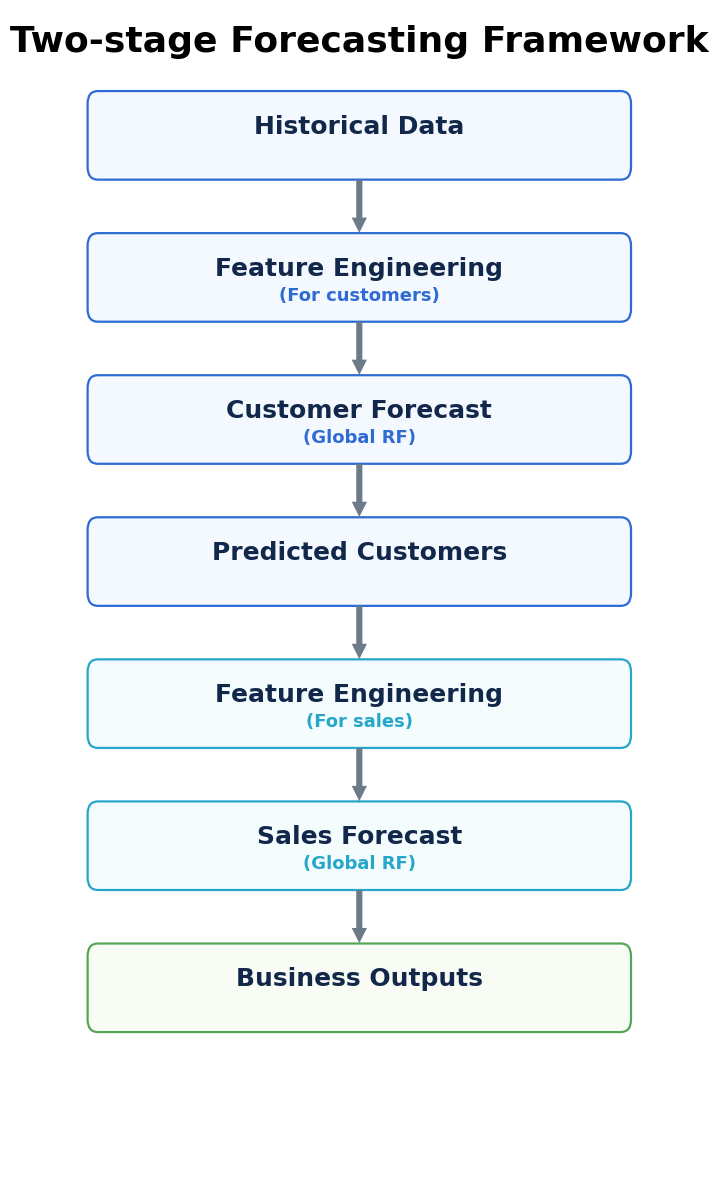

In [125]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ==========================
# Figure
# ==========================
fig, ax = plt.subplots(figsize=(8, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis("off")

# ==========================
# Title
# ==========================
ax.text(
    5,
    13.5,
    "Two-stage Forecasting Framework",
    fontsize=26,
    fontweight="bold",
    ha="center",
)

# ==========================
# Box information
# (text, subtitle, edge color, fill color)
# ==========================
boxes = [
    ("Historical Data", "", "#2E6BD3", "#F4F8FF"),

    ("Feature Engineering", "(For customers)",
     "#2E6BD3", "#F4F8FF"),

    ("Customer Forecast", "(Global RF)",
     "#2E6BD3", "#F4F8FF"),

    ("Predicted Customers", "",
     "#2E6BD3", "#F4F8FF"),

    ("Feature Engineering", "(For sales)",
     "#26A6C9", "#F4FCFE"),

    ("Sales Forecast", "(Global RF)",
     "#26A6C9", "#F4FCFE"),

    ("Business Outputs", "",
     "#55A657", "#F9FCF5"),
]

# ==========================
# Draw boxes
# ==========================
box_width = 7.8
box_height = 1.0
x = 1.1
start_y = 12

centers = []

for i, (title, subtitle, edge, face) in enumerate(boxes):

    y = start_y - i * 1.7

    box = FancyBboxPatch(
        (x, y),
        box_width,
        box_height,
        boxstyle="round,pad=0.03,rounding_size=0.15",
        linewidth=1.6,
        edgecolor=edge,
        facecolor=face,
    )

    ax.add_patch(box)

    ax.text(
        x + box_width / 2,
        y + 0.60,
        title,
        fontsize=18,
        fontweight="bold",
        ha="center",
        va="center",
        color="#12284A",
    )

    if subtitle:
        ax.text(
            x + box_width / 2,
            y + 0.28,
            subtitle,
            fontsize=13,
            color=edge,
            ha="center",
            va="center",
            fontweight="bold",
        )

    centers.append((x + box_width / 2, y))

# ==========================
# Draw arrows
# ==========================
for i in range(len(centers) - 1):

    x1 = centers[i][0]
    y1 = centers[i][1]

    x2 = centers[i + 1][0]
    y2 = centers[i + 1][1]

    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2 + box_height),
        arrowstyle="simple",
        mutation_scale=22,
        color="#6C7A89",
        linewidth=0,
    )

    ax.add_patch(arrow)

plt.tight_layout()

plt.savefig(
    processed_dir /"two_stage_forecasting_framework.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

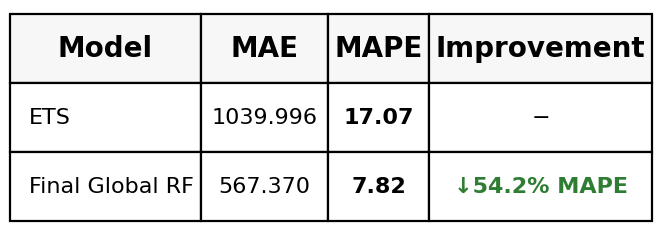

In [129]:
import matplotlib.pyplot as plt

# -----------------------------
# Data
# -----------------------------
columns = ["Model", "MAE", "MAPE", "Improvement"]

data = [
    ["ETS", "1039.996", "17.07", "−"],
    ["Final Global RF", "567.370", "7.82", "↓54.2% MAPE"]
]

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(8.2, 2.8))
ax.axis('off')

# -----------------------------
# Table
# -----------------------------
table = ax.table(
    cellText=data,
    colLabels=columns,
    loc='center',
    cellLoc='center',
    colLoc='center',
    colWidths=[0.30, 0.20, 0.16, 0.35]
)

table.auto_set_font_size(False)
table.set_fontsize(16)

# -----------------------------
# Style
# -----------------------------
for (row, col), cell in table.get_celld().items():

    cell.set_edgecolor("black")
    cell.set_linewidth(1.6)
    cell.set_height(0.32)

    # Header
    if row == 0:
        cell.set_facecolor("#F7F7F7")
        cell.get_text().set_weight("bold")
        cell.get_text().set_fontsize(20)

# -----------------------------
# Bold MAPE values
# -----------------------------
table[(1,2)].get_text().set_weight("bold")
table[(2,2)].get_text().set_weight("bold")

# -----------------------------
# Improvement (green)
# -----------------------------
table[(2,3)].get_text().set_color("#2E7D32")
table[(2,3)].get_text().set_weight("bold")

# -----------------------------
# Left align first column
# -----------------------------
for r in [1,2]:
    table[(r,0)].get_text().set_ha("left")

# -----------------------------
# Save
# -----------------------------
plt.savefig(
    processed_dir/"model_comparison_table.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

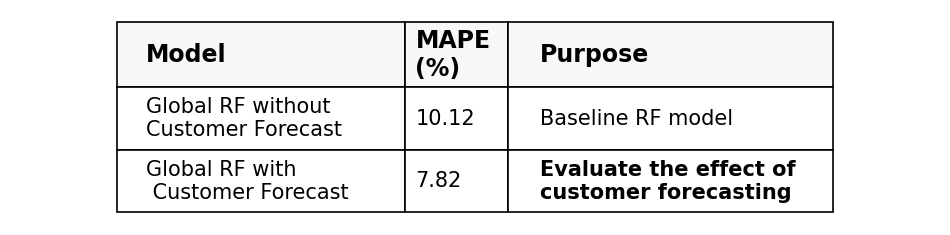

In [145]:
import matplotlib.pyplot as plt

# ============================
# Data
# ============================

columns = ["Model", "MAPE\n(%)", "Purpose"]

data = [
    [

        "Global RF without\nCustomer Forecast ",
        "10.12",
        "Baseline RF model"
    ],
    [

        "Global RF with\n Customer Forecast",
        "7.82",
        "Evaluate the effect of\ncustomer forecasting"
    ]
]

# ============================
# Figure
# ============================

fig, ax = plt.subplots(figsize=(12, 2.8))
ax.axis("off")

table = ax.table(
    cellText=data,
    colLabels=columns,
    loc="center",
    cellLoc="left",
    colLoc="left",
    colWidths=[0.31, 0.11, 0.35]
)

table.auto_set_font_size(False)
table.set_fontsize(15)

# ============================
# Style
# ============================

for (row, col), cell in table.get_celld().items():

    cell.set_edgecolor("black")
    cell.set_linewidth(1.2)

    if row == 0:
        cell.set_facecolor("#F8F8F8")
        cell.get_text().set_weight("bold")
        cell.get_text().set_fontsize(17)
        cell.set_height(0.30)
    else:
        cell.set_height(0.29)

# Center MAPE column
for r in [1, 2]:
    table[(r, 2)]._loc = "center"

# Bold Enhancement MAPE
table[(2, 2)].get_text().set_weight("bold")

# ============================
# Save
# ============================

plt.savefig(
    processed_dir / "stage_comparison_table.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)


plt.show()

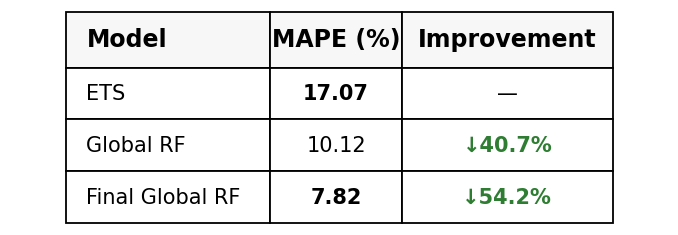

In [149]:
import matplotlib.pyplot as plt

# ======================================
# Data
# ======================================

columns = ["Model", "MAPE (%)", "Improvement"]

data = [
    ["ETS", "17.07", "—"],
    ["Global RF", "10.12", "↓40.7%"],
    ["Final Global RF", "7.82", "↓54.2%"],
]

# ======================================
# Figure
# ======================================

fig, ax = plt.subplots(figsize=(8.5, 2.8))
ax.axis("off")

table = ax.table(
    cellText=data,
    colLabels=columns,
    loc="center",
    cellLoc="center",
    colLoc="center",
    colWidths=[0.31, 0.20, 0.32],
)

table.auto_set_font_size(False)
table.set_fontsize(15)

# ======================================
# Style
# ======================================

for (r, c), cell in table.get_celld().items():

    cell.set_edgecolor("black")
    cell.set_linewidth(1.3)

    if r == 0:
        cell.set_facecolor("#F7F7F7")
        cell.get_text().set_weight("bold")
        cell.get_text().set_fontsize(17)
        cell.set_height(0.26)
    else:
        cell.set_height(0.24)

# Left align first column
for r in range(4):
    table[(r, 0)].get_text().set_ha("left")

# Bold best result
table[(1, 1)].get_text().set_weight("bold")      # ETS
table[(3, 1)].get_text().set_weight("bold")      # Final RF

# Green improvements
green = "#2E7D32"

table[(2, 2)].get_text().set_color(green)
table[(2, 2)].get_text().set_weight("bold")

table[(3, 2)].get_text().set_color(green)
table[(3, 2)].get_text().set_weight("bold")

# ======================================
# Save
# ======================================

plt.savefig(
    processed_dir / "1model_comparison_table.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)


plt.show()

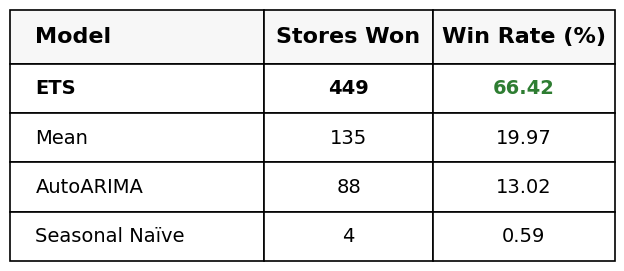

In [150]:
import matplotlib.pyplot as plt

# ======================================
# Data
# ======================================

columns = [
    "Model",
    "Stores Won",
    "Win Rate (%)"
]

data = [
    ["ETS", "449", "66.42"],
    ["Mean", "135", "19.97"],
    ["AutoARIMA", "88", "13.02"],
    ["Seasonal Naïve", "4", "0.59"],
]

# ======================================
# Figure
# ======================================

fig, ax = plt.subplots(figsize=(7.8, 3.2))
ax.axis("off")

table = ax.table(
    cellText=data,
    colLabels=columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.42, 0.28, 0.30]
)

table.auto_set_font_size(False)
table.set_fontsize(14)

# ======================================
# Style
# ======================================

green = "#2E7D32"

for (r, c), cell in table.get_celld().items():

    cell.set_edgecolor("black")
    cell.set_linewidth(1.2)

    if r == 0:
        cell.set_facecolor("#F7F7F7")
        cell.get_text().set_weight("bold")
        cell.get_text().set_fontsize(16)
        cell.set_height(0.22)

    else:
        cell.set_height(0.20)

# Left align model names
for r in range(5):
    table[(r, 0)].get_text().set_ha("left")

# Highlight ETS row
table[(1, 0)].get_text().set_weight("bold")
table[(1, 1)].get_text().set_weight("bold")
table[(1, 2)].get_text().set_weight("bold")

table[(1, 2)].get_text().set_color(green)

# ======================================
# Save
# ======================================

plt.savefig(
    processed_dir / "validation_best_model_by_store.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()